# Probabilidad y Diseño de Muestreo

## Objetivo

En esta sección del proyecto se modelan los eventos estadísticos asociados a los hábitos saludables de estudiantes universitarios.

Además, se establece el espacio muestral, se define el tipo de muestreo y se simula un dataset con más de 100 registros que será utilizado en las siguientes etapas del análisis estadístico.

## Contenidos

En este notebook se desarrollarán los siguientes puntos:

- Definición de eventos aleatorios
- Representación conceptual mediante árbol de probabilidades
- Diseño del plan de muestreo
- Simulación de un dataset
- Cálculo de probabilidades básicas

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
"""
## Espacio Muestral

El espacio muestral corresponde al conjunto de todos los posibles resultados del estudio.

En este proyecto, cada elemento del espacio muestral representa a un estudiante universitario con distintos hábitos de salud.

Las variables consideradas incluyen:

- Edad
- Género
- Horas de sueño
- Horas de ejercicio semanal
- Consumo de comida rápida
- Nivel de estrés
- Promedio académico (GPA)
"""

'\n## Espacio Muestral\n\nEl espacio muestral corresponde al conjunto de todos los posibles resultados del estudio.\n\nEn este proyecto, cada elemento del espacio muestral representa a un estudiante universitario con distintos hábitos de salud.\n\nLas variables consideradas incluyen:\n\n- Edad\n- Género\n- Horas de sueño\n- Horas de ejercicio semanal\n- Consumo de comida rápida\n- Nivel de estrés\n- Promedio académico (GPA)\n'

## Definición de Eventos Aleatorios

Un evento es un subconjunto del espacio muestral.

Para este estudio definimos algunos eventos relevantes:

A = El estudiante duerme menos de 6 horas por noche  
B = El estudiante realiza más de 3 horas de ejercicio por semana  
C = El estudiante presenta un nivel de estrés alto (mayor o igual a 7)

In [4]:
n = 150 #numero de estudiantes o muestras

data = pd.DataFrame({

    "edad": np.random.randint(18, 30, n),

    "genero": np.random.choice(["Masculino", "Femenino"], n),

    "horas_sueno": np.random.normal(6.5, 1.2, n).round(1),

    "horas_ejercicio": np.abs(np.random.normal(3, 1.5, n)).round(1),

    "comida_rapida_semana": np.random.poisson(2, n),

    "estres": np.random.randint(1, 11, n),

    "Prom_academico": np.round(np.random.normal(5.5, 0.5, n),2)
})

data.head()

,edad,genero,horas_sueno,horas_ejercicio,comida_rapida_semana,estres,Prom_academico
0,18,Masculino,6.9,2.0,0,6,5.98
1,25,Femenino,5.6,1.2,2,10,6.31
2,28,Femenino,7.6,0.7,1,8,4.88
3,20,Masculino,6.3,1.2,3,3,5.20
4,28,Femenino,6.1,3.1,4,10,5.49


In [5]:
data

,edad,genero,horas_sueno,horas_ejercicio,comida_rapida_semana,estres,Prom_academico
0,18,Masculino,6.9,2.0,0,6,5.98
1,25,Femenino,5.6,1.2,2,10,6.31
2,28,Femenino,7.6,0.7,1,8,4.88
3,20,Masculino,6.3,1.2,3,3,5.20
4,28,Femenino,6.1,3.1,4,10,5.49
...,...,...,...,...,...,...,...
145,27,Masculino,5.7,3.0,3,10,5.59
146,27,Masculino,6.9,6.5,3,2,6.40
147,29,Masculino,7.7,3.6,1,3,6.12
148,26,Masculino,5.0,3.3,2,1,5.60


In [7]:
#guardar el dataset
data.to_csv("habitos_saludables_estudiantes.csv", index=False)

In [9]:
!pwd

/content


In [10]:
#exploracion del dataset
data.describe()

,edad,horas_sueno,horas_ejercicio,comida_rapida_semana,estres,Prom_academico
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,23.633333,6.448667,2.936667,1.946667,5.280000,5.503667
std,3.435731,1.307117,1.431356,1.314793,3.021445,0.511510
min,18.000000,3.600000,0.300000,0.000000,1.000000,3.990000
25%,21.000000,5.600000,1.900000,1.000000,3.000000,5.192500
50%,24.000000,6.600000,2.900000,2.000000,5.000000,5.495000
75%,27.000000,7.375000,3.975000,3.000000,8.000000,5.820000
max,29.000000,10.300000,6.900000,7.000000,10.000000,7.070000


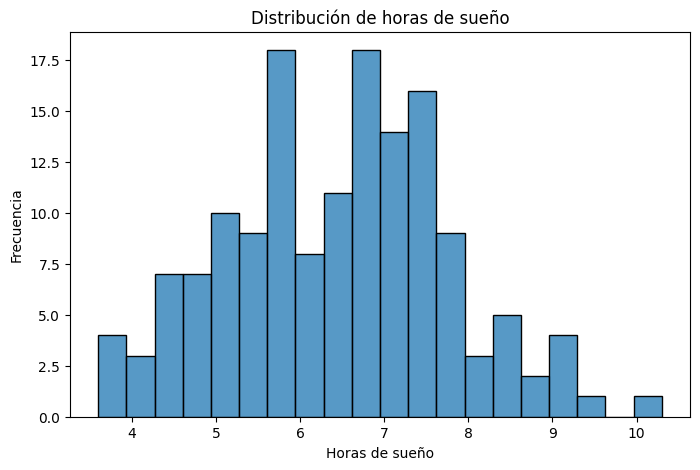

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(data["horas_sueno"], bins=20)

plt.title("Distribución de horas de sueño")
plt.xlabel("Horas de sueño")
plt.ylabel("Frecuencia")

plt.show()

In [12]:
#definiendo evento
evento_A = data["horas_sueno"] < 6
evento_B = data["horas_ejercicio"] > 3
evento_C = data["estres"] >= 7

In [13]:
P_A = evento_A.mean()
P_B = evento_B.mean()
P_C = evento_C.mean()

print("P(A) Dormir menos de 6 horas:", P_A)
print("P(B) Ejercicio > 3 horas:", P_B)
print("P(C) Estrés alto:", P_C)

P(A) Dormir menos de 6 horas: 0.38666666666666666
P(B) Ejercicio > 3 horas: 0.44
P(C) Estrés alto: 0.4066666666666667


In [15]:
#Intersección de eventos: (Estudiantes que duermen poco y tienen estrés alto)

P_A_inter_C = (evento_A & evento_C).mean()

print("P(A ∩ C):", P_A_inter_C)

P(A ∩ C): 0.15333333333333332


In [16]:
#Union de eventos
P_A_union_C = (evento_A | evento_C).mean()

print("P(A ∪ C):", P_A_union_C)

P(A ∪ C): 0.64


In [17]:
#Evento complementarios
P_no_A = 1 - P_A

print("P(no A):", P_no_A)

P(no A): 0.6133333333333333


## Conclusiones

Se generó un dataset simulado de 150 estudiantes universitarios con variables relacionadas a hábitos de salud.

A partir de este conjunto de datos se definieron eventos aleatorios asociados a comportamientos relevantes como dormir pocas horas, realizar ejercicio físico o presentar niveles altos de estrés.

Además, se calcularon probabilidades básicas de eventos, intersecciones y uniones, lo que permite comenzar a modelar estadísticamente los patrones de comportamiento dentro de la población estudiantil.

Este dataset será utilizado en las siguientes etapas del proyecto para analizar distribuciones de probabilidad, aplicar el Teorema del Límite Central y realizar inferencias estadísticas.